# Marketing A/B Test  Conversion Analysis

Analysis of the Kaggle marketing A/B testing dataset. Goal: quantify the
lift in conversion rate for users exposed to ads vs. PSA control, and
identify how exposure volume and timing modulate the effect.

## 1. Setup

In [3]:
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

# R magic loaded for the interaction model + emmeans post-hoc
%load_ext rpy2.ipython

sns.set_theme(style="whitegrid")

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [4]:
# Download dataset from Kaggle and load into a DataFrame
path = kagglehub.dataset_download("faviovaz/marketing-ab-testing")
df = pd.read_csv(f"{path}/marketing_AB.csv")

# Drop the unnamed index column and rename to snake_case for formula APIs
df = df.drop(columns=["Unnamed: 0"]).rename(columns={
    "test group":    "test_group",
    "total ads":     "total_ads",
    "most ads day":  "most_ads_day",
    "most ads hour": "most_ads_hour",
})

df.head()

,user id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [5]:
# Bin total_ads into exposure categories for dose-response analysis
df["ads_bin"] = pd.cut(
    df["total_ads"],
    bins=[1, 6, 11, 21, 41, 81, 201, np.inf],
    right=False,
    labels=["1-5", "6-10", "11-20", "21-40", "41-80", "81-200", "200+"],
)

## 2. Descriptive statistics

In [6]:
# Group balance: ad vs. psa (imbalanced by design, ~96/4)
df["test_group"].value_counts(normalize=True)

test_group
ad     0.96
psa    0.04
Name: proportion, dtype: float64

In [7]:
# Exposure distribution per group; right-skewed with heavy tail
df.groupby("test_group")["total_ads"].agg(["mean", "median", "std", "max"])

,mean,median,std,max
test_group,,,,
ad,24.823365,13.0,43.750456,2065
psa,24.761138,12.0,42.860720,907


In [8]:
# Raw conversion rate per group
conv_by_group = df.groupby("test_group")["converted"].agg(["sum", "count", "mean"])
conv_by_group.columns = ["n_converted", "n_total", "rate"]
conv_by_group

,n_converted,n_total,rate
test_group,,,
ad,14423,564577,0.025547
psa,420,23524,0.017854


In [9]:
# Conversion rate crossed with day of week
conv_by_day = df.groupby(["test_group", "most_ads_day"])["converted"].agg(["sum", "count", "mean"])
conv_by_day.columns = ["n_converted", "n_total", "rate"]
conv_by_day.unstack()

n_converted                                                    \
most_ads_day      Friday Monday Saturday Sunday Thursday Tuesday Wednesday   
test_group                                                                   
ad                  1995   2778     1679   2027     1711    2270      1963   
psa                   62     79       40     63       79      42        55   

             n_total                  ...                             \
most_ads_day  Friday Monday Saturday  ... Thursday Tuesday Wednesday   
test_group                            ...                              
ad             88805  83571    78802  ...    79077   74572     77418   
psa             3803   3502     2858  ...     3905    2907      3490   

                  rate                                                    \
most_ads_day    Friday    Monday  Saturday    Sunday  Thursday   Tuesday   
test_group                                                                 
ad            0.022465  0.033241  0.021307  0.024620  0.021637  0.030440   
psa           0.016303  0.022559  0.013996  0.020595  0.020230  0.014448   

                        
most_ads_day Wednesday  
test_group              
ad            0.025356  
psa           0.015759  

[2 rows x 21 columns]

In [10]:
# Conversion rate crossed with exposure bin
df.groupby(["test_group", "ads_bin"], observed=True)["converted"].mean().unstack()

ads_bin,1-5,6-10,11-20,21-40,41-80,81-200,200+
test_group,,,,,,,
ad,0.002512,0.004853,0.008400,0.023227,0.084675,0.16961,0.155778
psa,0.002799,0.006735,0.008193,0.019775,0.046745,0.08985,0.155039


## 3. Hypothesis testing — two-proportion z-test

H0: conversion rate in the ad group equals that of the psa group.

In [11]:
# Successes and totals for each group, ordered [ad, psa]
count = conv_by_group["n_converted"].loc[["ad", "psa"]].values
nobs  = conv_by_group["n_total"].loc[["ad", "psa"]].values

z_stat, p_value = proportions_ztest(count, nobs)

rate_ad, rate_psa = count / nobs
lift_abs = (rate_ad - rate_psa) * 100
lift_rel = (rate_ad / rate_psa - 1) * 100

print(f"Ad  conversion rate : {rate_ad:.2%}")
print(f"PSA conversion rate : {rate_psa:.2%}")
print(f"Absolute lift       : {lift_abs:+.2f} pp")
print(f"Relative lift       : {lift_rel:+.1f} %")
print(f"z = {z_stat:.2f}, p = {p_value:.3g}")

Ad  conversion rate : 2.55%
PSA conversion rate : 1.79%
Absolute lift       : +0.77 pp
Relative lift       : +43.1 %
z = 7.37, p = 1.71e-13


In [21]:
count

array([14423,   420])

In [ ]:
%%R -i df -i count -i nobs -o emm_df

#Set a bootstrap due to imbalance in A/B group, with 95% CI

set.seed(42)
n_boot <- 10000

conv_ad  <- count[1] # es. 14728
n_ad     <- nobs[1]  # es. 564577
conv_psa <- count[2] # es. 562
n_psa    <- nobs[2]  # es. 23524

rate_ad  <- conv_ad / n_ad
rate_psa <- conv_psa / n_psa

boot_ad  <- rbinom(n = n_boot, size = n_ad, prob = rate_ad) / n_ad
boot_psa <- rbinom(n = n_boot, size = n_psa, prob = rate_psa) / n_psa

boot_lift_abs <- (boot_ad - boot_psa) * 100
boot_lift_rel <- ((boot_ad / boot_psa) - 1) * 100

ci_abs <- quantile(boot_lift_abs, probs = c(0.025, 0.975))
ci_rel <- quantile(boot_lift_rel, probs = c(0.025, 0.975))

#Print the results
cat("Bootstrap CI 95% (Absolute Lift): [", sprintf("%+.2f", ci_abs[1]), "pp,", sprintf("%+.2f", ci_abs[2]), "pp ]\n")
cat("Bootstrap CI 95% (Relative Lift): [", sprintf("%+.1f", ci_rel[1]), "%,", sprintf("%+.1f", ci_rel[2]), "% ]\n")

Bootstrap CI 95% (Absolute Lift): [ +0.59 pp, +0.95 pp ]
Bootstrap CI 95% (Relative Lift): [ +30.3 %, +58.5 % ]


## 4. Exploratory visualization

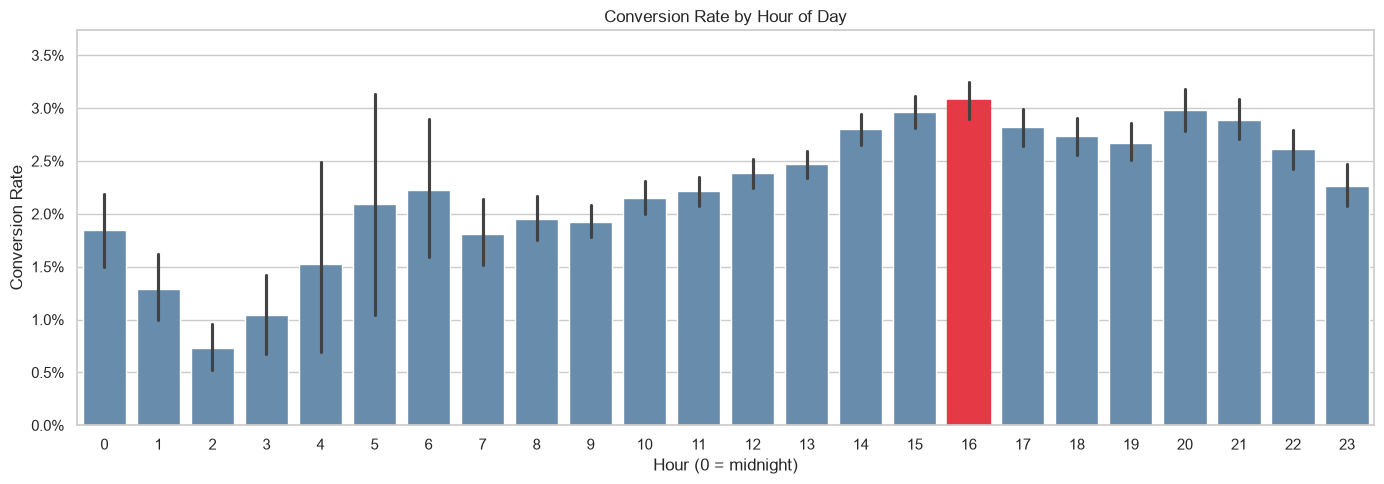

In [12]:
# Conversion rate by hour of day, highlighting the peak hour
fig, ax = plt.subplots(figsize=(14, 5))

sns.barplot(data=df, x="most_ads_hour", y="converted",
            estimator="mean", order=list(range(24)),
            color="#5B8DB8", ax=ax)

# Highlight the peak-conversion hour (16:00)
ax.patches[16].set_color("#E63946")

ax.set_title("Conversion Rate by Hour of Day")
ax.set_xlabel("Hour (0 = midnight)")
ax.set_ylabel("Conversion Rate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
ax.margins(y=0.15)

plt.tight_layout()
plt.show()

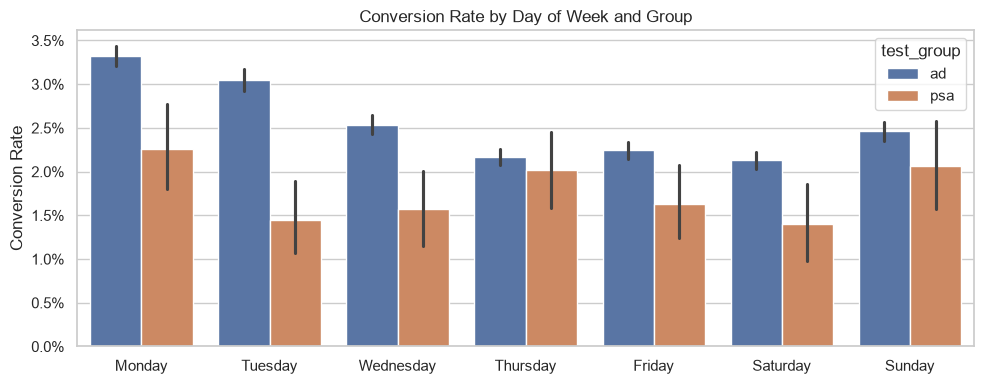

In [13]:
# Conversion rate by day of week, split by test group
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=df, x="most_ads_day", y="converted", hue="test_group",
            estimator="mean", order=day_order, ax=ax)
ax.set_title("Conversion Rate by Day of Week and Group")
ax.set_ylabel("Conversion Rate")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
plt.tight_layout()
plt.show()

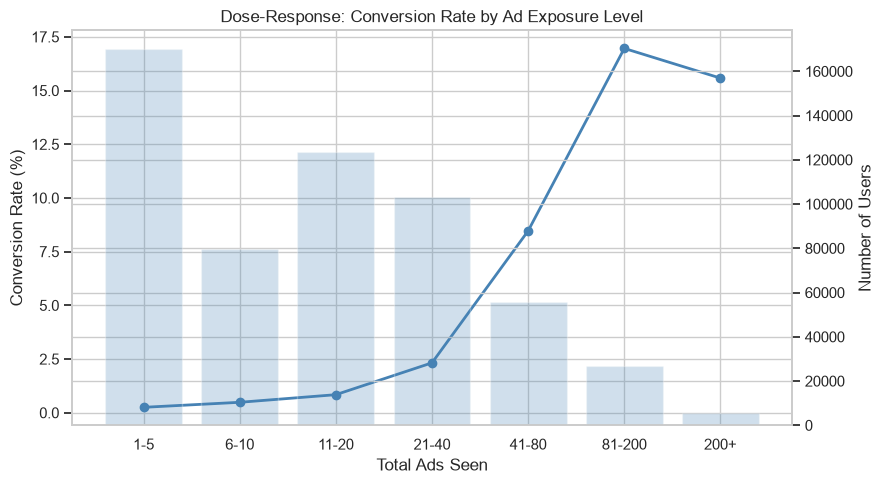

In [14]:
# Dose-response: conversion rate vs exposure bin, ad group only
sub = df[df["test_group"] == "ad"]
agg = sub.groupby("ads_bin", observed=True).converted.agg(["mean", "count"])

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax2.bar(agg.index.astype(str), agg["count"], alpha=0.25, color="steelblue", label="Users")
ax1.plot(agg.index.astype(str), agg["mean"] * 100, marker="o",
         color="steelblue", linewidth=2, label="Conversion rate")

ax1.set_ylabel("Conversion Rate (%)")
ax2.set_ylabel("Number of Users")
ax1.set_xlabel("Total Ads Seen")
ax1.set_title("Dose-Response: Conversion Rate by Ad Exposure Level")
plt.tight_layout()
plt.show()

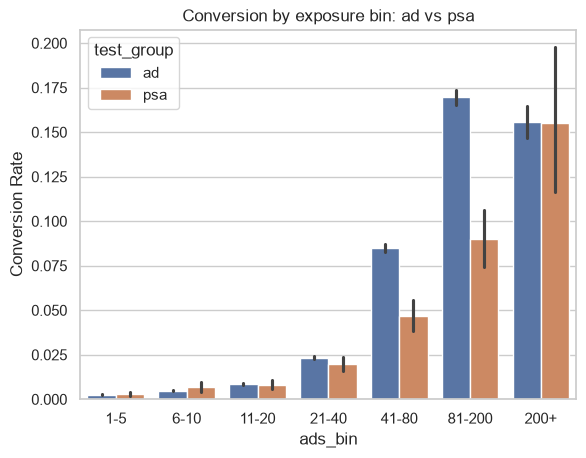

In [15]:
# Same dose-response, split by group, with 95% CIs
sns.barplot(data=df, x="ads_bin", y="converted",
            hue="test_group", errorbar=("ci", 95))
plt.ylabel("Conversion Rate")
plt.title("Conversion by exposure bin: ad vs psa")
plt.show()

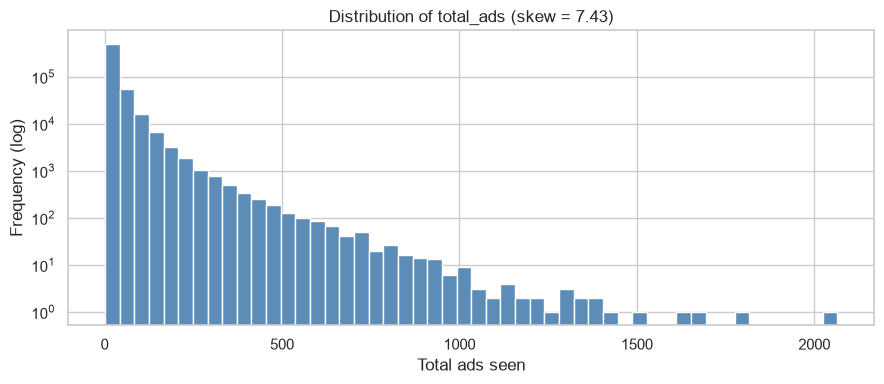

In [16]:
# total_ads is heavily right-skewed; log y-axis reveals the tail
fig, ax = plt.subplots(figsize=(9, 4))
df["total_ads"].hist(bins=50, ax=ax, color="#5B8DB8", edgecolor="white")
ax.set_yscale("log")
ax.set_xlabel("Total ads seen")
ax.set_ylabel("Frequency (log)")
ax.set_title(f"Distribution of total_ads (skew = {df['total_ads'].skew():.2f})")
plt.tight_layout()
plt.show()

## 5. Interaction model + post-hoc (R via rpy2)

Logistic GLM with `log_total_ads`, `test_group`, and the `hour × day`
interaction. `car::Anova` for Type-III omnibus tests, `emmeans` for
marginal means and Tukey-adjusted pairwise contrasts.

In [17]:
%%R -i df -o emm_df
library(emmeans); library(car)

# Cast categorical predictors and add log feature
df$most_ads_hour <- factor(df$most_ads_hour)
df$most_ads_day  <- factor(df$most_ads_day)
df$log_total_ads <- log1p(df$total_ads)

# Full model with hour * day interaction
m <- glm(converted ~ log_total_ads + test_group +
         most_ads_hour * most_ads_day,
         data = df, family = binomial)

# Type-III omnibus tests on each term (including the interaction)
print(Anova(m, type = 'III'))

# Estimated marginal means on the response scale, day nested within hour
emm <- emmeans(m, ~ most_ads_day | most_ads_hour, type = 'response')
emm_df <- as.data.frame(summary(emm))

Analysis of Deviance Table (Type III tests)

Response: converted
                           LR Chisq  Df Pr(>Chisq)    
log_total_ads               25804.2   1  < 2.2e-16 ***
test_group                     64.1   1  1.207e-15 ***
most_ads_hour                 107.6  23  6.750e-13 ***
most_ads_day                    5.7   6     0.4616    
most_ads_hour:most_ads_day    289.9 138  7.627e-13 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'
Caricamento del pacchetto richiesto: carData


In [ ]:
#As an alternativa due to imbalance in groups sample, it might be worthy to run a control analysis with brglmFit (Firth's Penalized Likelihood)

In [18]:
%%R -o significant_pairs
library(dplyr)

pairwise_comps <- pairs(emm, adjust = "tukey")

significant_pairs <- summary(pairwise_comps) %>%
  as.data.frame() %>%
  filter(p.value < 0.05)

print(significant_pairs)

R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xe8 in position 20: invalid continuation byte <traceback object at 0x0000019B825F9840>


most_ads_hour = 7:
 contrast             odds.ratio        SE  df null z.ratio p.value
 Saturday / Tuesday    0.3181406 0.1144560 Inf    1  -3.183  0.0245

most_ads_hour = 8:
 contrast             odds.ratio        SE  df null z.ratio p.value
 Friday / Monday       0.3587394 0.0737048 Inf    1  -4.990 <0.0001
 Monday / Saturday     1.8737001 0.3544774 Inf    1   3.319  0.0158
 Monday / Sunday       2.0824589 0.4102102 Inf    1   3.724  0.0037
 Monday / Thursday     1.9254999 0.3773834 Inf    1   3.343  0.0146
 Monday / Wednesday    1.9786565 0.4094633 Inf    1   3.298  0.0169

most_ads_hour = 9:
 contrast             odds.ratio        SE  df null z.ratio p.value
 Friday / Monday       0.6305808 0.0935653 Inf    1  -3.108  0.0311
 Monday / Saturday     1.9963511 0.3301473 Inf    1   4.180  0.0006
 Monday / Sunday       1.6237572 0.2584108 Inf    1   3.046  0.0375
 Monday / Wednesday    1.7352744 0.2629832 Inf    1   3.637  0.0051

most_ads_hour = 10:
 contrast             odds.ratio    


Caricamento pacchetto: 'dplyr'

I seguenti oggetti sono mascherati da 'package:stats':

    filter, lag

I seguenti oggetti sono mascherati da 'package:base':

    intersect, setdiff, setequal, union



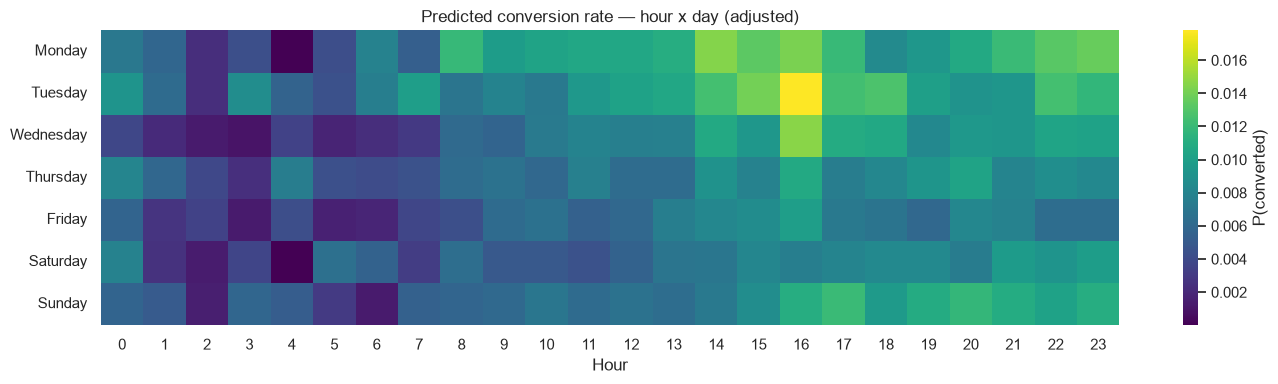

In [19]:
# Heatmap of predicted conversion probability across hour x day
pivot = (emm_df
         .pivot(index="most_ads_day", columns="most_ads_hour", values="prob")
         .reindex(day_order))

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, cmap="viridis", ax=ax,
            cbar_kws={"label": "P(converted)"})
ax.set_title("Predicted conversion rate — hour x day (adjusted)")
ax.set_xlabel("Hour")
ax.set_ylabel("")
plt.tight_layout()
plt.show()